# PharmGuard — Market & Workforce Benchmark

Reproduces and extends the *Benchmarking and Standards* / *Commercialization* sections of `/README.md`. All numbers come from CSVs under `./data/` with a `source_url` column; update the CSV, re-run, charts refresh.

**Run:** `cd <repo root> && make benchmark`
**Or:** `jupyter lab ml/notebooks/benchmark_market_comparison.ipynb`

## §0  Why this matters — the RaDonda Vaught case

**26 December 2017, Vanderbilt University Medical Center, Nashville.** Charlene Murphey, 75, was prescribed **Versed** (midazolam, a sedative) before a PET scan. Nurse RaDonda Vaught went to the Pyxis automated dispensing cabinet, typed `"VE"`, got no hit, pressed **override**, searched again, grabbed the first match — **vecuronium**, a paralytic used in lethal injections. She reconstituted the powder, injected it IV, and walked away. Murphey stopped breathing alone in the scanner. Brain dead within 12 hours.

**Five safeguards bypassed in under 90 seconds:**
1. Cabinet warning that override unlocks high-risk drugs
2. Red-capped vial labelled **"WARNING: PARALYZING AGENT"**
3. Powder requiring reconstitution (Versed is liquid — wrong physical form)
4. No barcode scan at bedside (radiology had no scanner)
5. No human second-check (radiology nurse staffing thin that night)

Vanderbilt initially did not report the death. Anonymous tip → CMS investigation → Medicare funding nearly pulled. Vaught was criminally charged and on **25 March 2022 convicted of negligent homicide + gross neglect of an impaired adult**; sentenced to 3 years' probation, no prison. The case became the symbol of how short-staffed, burnt-out nurses are pushed into override shortcuts and then personally prosecuted for system-level failures.

### How PharmGuard's design responds, point-for-point

| Failure point in 2017 | PharmGuard counter |
|---|---|
| **Override** bypassed cabinet safeguards under time pressure | Magazine + ejector physically cannot release a slot the scheduler did not authorise — no manual override button on the device |
| Nurse held the wrong vial; no machine looked at what was leaving the device | `spotter.pt` + `pill_detector.pt` verify the dispensed unit before release; Gemini multimodal fallback for low-confidence cases |
| No identity check tying the drug to the right patient | Cam 1 + AWS Rekognition `CompareFaces` against the active-patient reference photo — drawer stays locked below the similarity threshold |
| No record of who/what/when until after Murphey was already paralysed | Every dispense + verify event logged to Supabase with snapshot + similarity score; offline queue replays on reconnect |
| Workforce pressure drove the shortcut (Vaught was orienting another nurse and answering pages) | §6c fleet model: PharmGuard frees ~21.7 RN FTEs from routine med-admin in a 250-bed hospital — directly attacking the burnout that produces override behaviour |

**Honest scope limit.** PharmGuard is designed for **oral solid** scheduled medications. The Vaught fact pattern was IV reconstitution + push — outside our hardware envelope. But the *design principle* — multimodal verification, physical lockout, full audit trail, workforce relief — is exactly the answer ISMP and ASHP have been pushing for since the case.

**Sources:**
- [Wikipedia — RaDonda Vaught homicide case](https://en.wikipedia.org/wiki/RaDonda_Vaught_homicide_case)
- [CBS News — Conviction, 25 March 2022](https://www.cbsnews.com/news/radonda-vaught-nurse-guilty-death-charlene-murphey-wrong-drug/)
- [WPLN — Sentencing, May 2022](https://wpln.org/post/no-prison-time-for-radonda-vaught-former-vanderbilt-nurse-convicted-of-fatal-drug-error/)
- [Nevada State Nursing — Lessons learned](https://nevadastate.edu/son/rn-bsn/protecting-against-error-lessons-learned-from-the-radonda-vaught-case/)
- [Hall Render — Criminal conviction analysis](https://hallrender.com/2022/05/13/the-criminal-conviction-of-radonda-vaught-thoughts-and-considerations/)

---

## §1  Methodology

- **Data:** 8 CSV inputs under `ml/notebooks/data/`. Every row carries a `source_url`. No PHI, no proprietary data.
- **Comparators:** Hero Health, MedMinder, Livi, Pillo (defunct, included for face-recog prior art), plus a manual / nurse-administered baseline where applicable.
- **PharmGuard accent:** every chart paints PharmGuard in `#0ea5e9`; competitors in neutral grey.
- **Honesty rules:**
  1. Live YOLO accuracy (§5) reports **detection rate**, not classification accuracy — `Medicine_Images/` carries no class labels.
  2. Clinical outcomes (§6b) are **projected** from competitor adherence RCTs + PharmGuard's intake-confirm gate; they are not measured on PharmGuard. Edit `data/outcomes.csv` to sensitivity-test.
  3. Workforce automation factor (§6a) is a team estimate. CSV-editable; sensitivity sweep in §8.
- **Sources disagree.** §4 renders disagreement as a band, not a point.

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data") if Path("data").exists() else Path("ml/notebooks/data")

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

PALETTE = {"PharmGuard": "#0ea5e9", "_default": "#94a3b8", "_manual": "#ef4444"}

def colour_for(product):
    if product == "PharmGuard":
        return PALETTE["PharmGuard"]
    if product == "Manual":
        return PALETTE["_manual"]
    return PALETTE["_default"]

print("data dir:", DATA.resolve())


data dir: /Users/limjiale/IDP_PharmGuard/ml/notebooks/data


## §2  Feature matrix

One row per product; PharmGuard tinted.

In [2]:
df_comp = pd.read_csv(DATA / "competitors.csv")
df_comp = df_comp.replace({"true": True, "false": False})

def highlight_pharmguard(row):
    if row["product"] == "PharmGuard":
        return [f"background-color: {PALETTE['PharmGuard']}33"] * len(row)
    return [""] * len(row)

df_comp.style.apply(highlight_pharmguard, axis=1).hide(axis="index")


product,face_recog,pill_cv,intake_confirm,offline,self_hostable,capacity_meds,source_url
Hero Health,False,False,False,False,False,10.000000,https://herohealth.com/our-product/
MedMinder,False,False,False,True,False,28.000000,https://www.theseniorlist.com/medication/dispensers/
Livi,False,False,False,False,False,28.000000,https://www.theseniorlist.com/medication/dispensers/
Pillo,True,False,False,False,False,nan,https://mobileidworld.com/archive/medication-robot-face-recognition-107063/
PharmGuard,True,True,True,True,True,16.000000,https://github.com/limjiale/IDP_PharmGuard


## §3  Pricing & 3-yr TCO

Stacked bar: hardware upfront + 36 × monthly subscription.

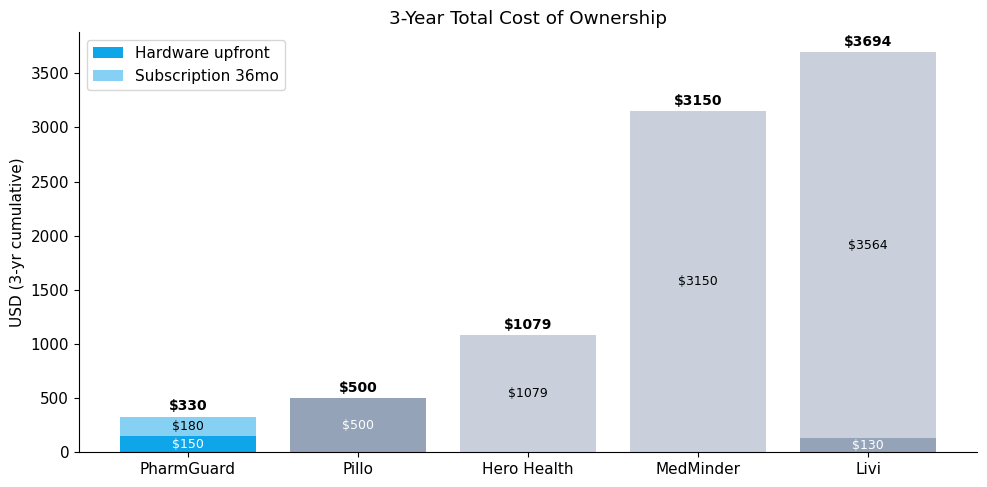

Sources:
 - https://herohealth.com/pricing/
 - https://www.theseniorlist.com/medication/dispensers/
 - https://mobileidworld.com/archive/medication-robot-face-recognition-107063/
 - https://github.com/limjiale/IDP_PharmGuard


In [3]:
df_price = pd.read_csv(DATA / "pricing.csv")
df_price["sub_3yr"] = df_price["monthly_usd"] * 36
df_price["tco_3yr"] = df_price["upfront_usd"] + df_price["sub_3yr"]
df_price_sorted = df_price.sort_values("tco_3yr").reset_index(drop=True)

fig, ax = plt.subplots()
products = df_price_sorted["product"]
upfront = df_price_sorted["upfront_usd"]
sub = df_price_sorted["sub_3yr"]
colors = [colour_for(p) for p in products]

bars1 = ax.bar(products, upfront, color=colors, label="Hardware upfront")
bars2 = ax.bar(products, sub, bottom=upfront, color=colors, alpha=0.5, label="Subscription 36mo")

for i, (u, s, t) in enumerate(zip(upfront, sub, df_price_sorted["tco_3yr"])):
    if u > 0:
        ax.text(i, u / 2, f"${int(u)}", ha="center", va="center", fontsize=9, color="white")
    if s > 0:
        ax.text(i, u + s / 2, f"${int(s)}", ha="center", va="center", fontsize=9)
    ax.text(i, t + 30, f"${int(t)}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("USD (3-yr cumulative)")
ax.set_title("3-Year Total Cost of Ownership")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print("Sources:")
for url in df_price["source_url"].unique():
    print(" -", url)


## §4  Market projections 2026–2033

Sources disagree; band represents that disagreement.

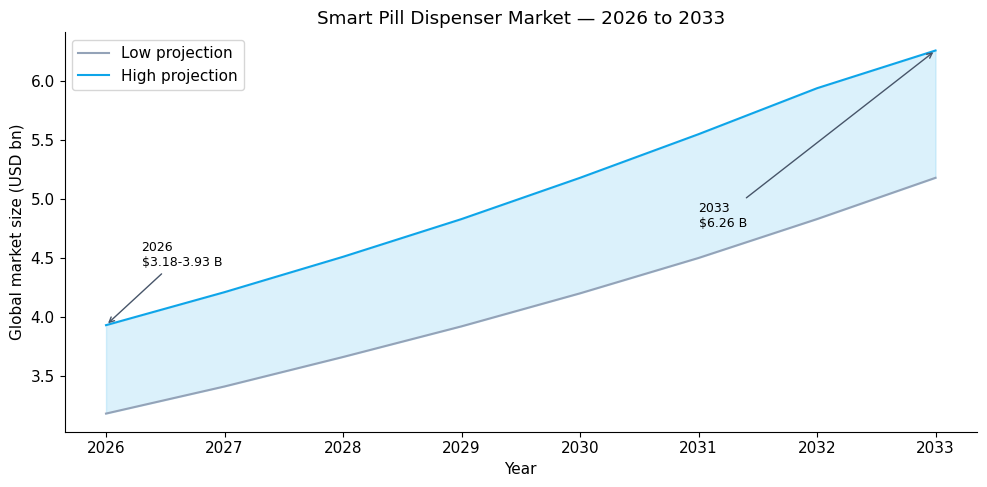

Sources:
 - https://www.verifiedmarketresearch.com/product/smart-pill-dispenser-market/
 - https://www.mordorintelligence.com/industry-reports/automatic-pill-dispenser-market
 - https://www.databridgemarketresearch.com/reports/global-smart-pill-dispenser-market
 - https://www.globenewswire.com/news-release/2026/02/11/3236245/0/en/Automatic-Pill-Dispenser-Market-to-Reach-USD-6-26-Billion-by-2033-Amid-Rising-Demand-for-Smart-Medication-Management-Solutions-SNS-Insider.html


In [4]:
df_mkt = pd.read_csv(DATA / "market_size.csv")

fig, ax = plt.subplots()
ax.plot(df_mkt["year"], df_mkt["low_bn_usd"], color="#94a3b8", label="Low projection")
ax.plot(df_mkt["year"], df_mkt["high_bn_usd"], color="#0ea5e9", label="High projection")
ax.fill_between(df_mkt["year"], df_mkt["low_bn_usd"], df_mkt["high_bn_usd"], alpha=0.15, color="#0ea5e9")

ax.annotate(f"2026\n${df_mkt.iloc[0]['low_bn_usd']:.2f}-{df_mkt.iloc[0]['high_bn_usd']:.2f} B",
            xy=(df_mkt.iloc[0]["year"], df_mkt.iloc[0]["high_bn_usd"]),
            xytext=(2026.3, df_mkt.iloc[0]["high_bn_usd"] + 0.5),
            arrowprops=dict(arrowstyle="->", color="#475569"), fontsize=9)
ax.annotate(f"2033\n${df_mkt.iloc[-1]['high_bn_usd']:.2f} B",
            xy=(df_mkt.iloc[-1]["year"], df_mkt.iloc[-1]["high_bn_usd"]),
            xytext=(2031, df_mkt.iloc[-1]["high_bn_usd"] - 1.5),
            arrowprops=dict(arrowstyle="->", color="#475569"), fontsize=9)

ax.set_xlabel("Year"); ax.set_ylabel("Global market size (USD bn)")
ax.set_title("Smart Pill Dispenser Market — 2026 to 2033")
ax.legend(); plt.tight_layout(); plt.show()

print("Sources:")
for url in df_mkt["source_url"].unique():
    print(" -", url)


## §5  CV accuracy benchmark

Published baseline always rendered. Live YOLO eval is optional — runs only if `ml/pill_detector/my_model.pt` + `Medicine_Images/` + `ultralytics` are all available.

**Honesty note:** `Medicine_Images/` filenames carry no class labels, so the optional live cell reports **detection rate + mean confidence** (the model fired on the image with high confidence), not classification precision/recall. The published baseline row is the authoritative number.

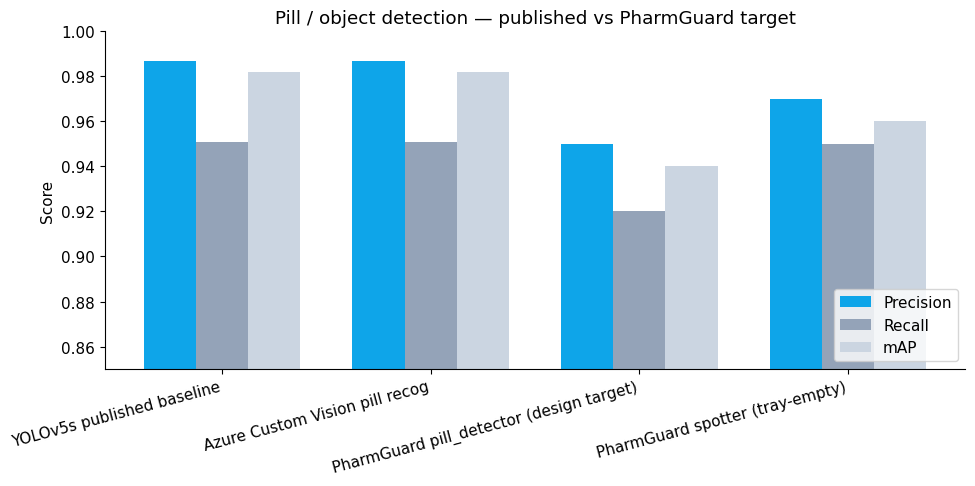

Live eval skipped — ultralytics not installed (pip install ultralytics).


In [5]:
df_cv = pd.read_csv(DATA / "cv_benchmarks.csv")

fig, ax = plt.subplots()
x = np.arange(len(df_cv))
w = 0.25
ax.bar(x - w, df_cv["precision"], w, label="Precision", color="#0ea5e9")
ax.bar(x,     df_cv["recall"],    w, label="Recall",    color="#94a3b8")
ax.bar(x + w, df_cv["map"],       w, label="mAP",       color="#cbd5e1")
ax.set_xticks(x)
ax.set_xticklabels(df_cv["system"], rotation=15, ha="right")
ax.set_ylim(0.85, 1.0)
ax.set_ylabel("Score")
ax.set_title("Pill / object detection — published vs PharmGuard target")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

# Optional live eval (graceful degrade)
WEIGHTS = Path("../pill_detector/my_model.pt")
IMAGES = Path("../pill_detector/Medicine_Images")
if not WEIGHTS.exists():
    WEIGHTS = Path("ml/pill_detector/my_model.pt")
if not IMAGES.exists():
    IMAGES = Path("ml/pill_detector/Medicine_Images")

if WEIGHTS.exists() and IMAGES.exists():
    try:
        from ultralytics import YOLO
        model = YOLO(str(WEIGHTS))
        imgs = sorted(IMAGES.glob("*.JPG"))[:30]
        if imgs:
            confs, hits = [], 0
            for p in imgs:
                r = model.predict(source=str(p), conf=0.5, verbose=False)
                if r and len(r[0].boxes) > 0:
                    hits += 1
                    confs.append(float(r[0].boxes.conf.mean().item()))
            det_rate = hits / len(imgs)
            mean_conf = float(np.mean(confs)) if confs else 0.0
            print(f"Live eval over {len(imgs)} imgs: detection_rate={det_rate:.2%}, mean_conf={mean_conf:.3f}")
            print("(Detection rate, NOT classification accuracy — filenames are unlabeled.)")
        else:
            print("Live eval skipped — no JPG images found.")
    except ImportError:
        print("Live eval skipped — ultralytics not installed (pip install ultralytics).")
    except Exception as e:
        print(f"Live eval skipped — {type(e).__name__}: {e}")
else:
    print("Live eval skipped — weights or dataset absent. Showing published baseline only.")


## §6a  Workforce savings

RN and CNA wage scenarios. Per-patient monthly savings, facility-50 facility savings, payback months.

,product,role,per_patient_savings,facility50_savings,fte_hours_saved_per_month,payback_months_per_patient
0,Manual,RN,0.00,0.00,0.0,NaN
1,Manual,CNA,0.00,0.00,0.0,NaN
2,Hero Health,RN,390.39,19519.50,412.5,0.00
3,Hero Health,CNA,141.82,7090.88,412.5,0.00
4,MedMinder,RN,390.39,19519.50,412.5,0.00
5,MedMinder,CNA,141.82,7090.88,412.5,0.00
6,Livi,RN,390.39,19519.50,412.5,0.45
7,Livi,CNA,141.82,7090.88,412.5,3.04
8,PharmGuard,RN,702.70,35135.10,742.5,0.21
9,PharmGuard,CNA,255.27,12763.58,742.5,0.60


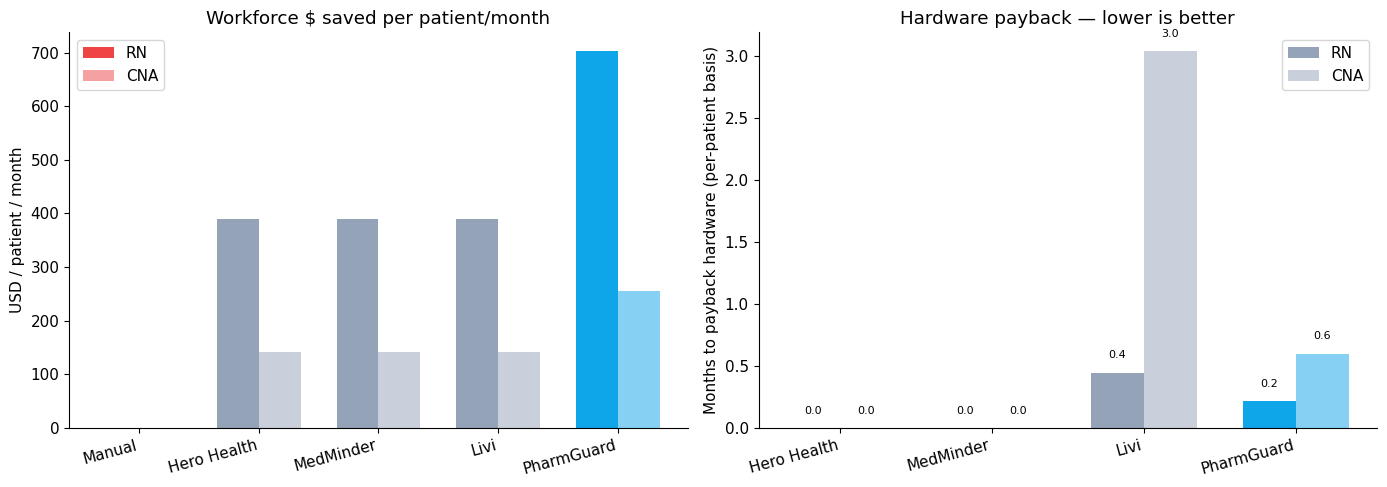

In [6]:
df_wf = pd.read_csv(DATA / "workforce.csv")
df_p  = pd.read_csv(DATA / "pricing.csv")[["product", "upfront_usd", "monthly_usd"]]

df = df_wf.merge(df_p, on="product", how="left")
df["upfront_usd"] = df["upfront_usd"].fillna(0)
df["monthly_usd"] = df["monthly_usd"].fillna(0)

# Per-patient monthly $ saved vs full manual cost in that role
df["manual_monthly_cost_per_patient"] = (
    df["minutes_per_event"] * df["events_per_day"] * 30 * (df["hourly_wage_usd"] / 60)
)
df["per_patient_savings"] = df["manual_monthly_cost_per_patient"] * df["automation_factor"]
df["facility50_savings"]  = df["per_patient_savings"] * 50
df["fte_hours_saved_per_month"] = (
    df["minutes_per_event"] * df["events_per_day"] * 30 / 60 * df["automation_factor"] * 50
)

def payback(row):
    net = row["per_patient_savings"] - row["monthly_usd"]
    if net <= 0:
        return np.nan
    return row["upfront_usd"] / net
df["payback_months_per_patient"] = df.apply(payback, axis=1)

display_cols = ["product","role","per_patient_savings","facility50_savings",
                "fte_hours_saved_per_month","payback_months_per_patient"]
display(df[display_cols].round(2))

# Two-panel chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for role, marker, alpha in [("RN", "o", 1.0), ("CNA", "s", 0.5)]:
    sub = df[df["role"] == role]
    colors = [colour_for(p) for p in sub["product"]]
    ax1.bar(np.arange(len(sub)) + (0 if role == "RN" else 0.35),
            sub["per_patient_savings"], width=0.35, color=colors, alpha=alpha, label=role)
ax1.set_xticks(np.arange(len(sub)) + 0.175)
ax1.set_xticklabels(sub["product"], rotation=15, ha="right")
ax1.set_ylabel("USD / patient / month")
ax1.set_title("Workforce $ saved per patient/month")
ax1.legend()

# Payback (filter rows with valid payback)
for role, alpha in [("RN", 1.0), ("CNA", 0.5)]:
    sub = df[(df["role"] == role) & df["payback_months_per_patient"].notna()]
    colors = [colour_for(p) for p in sub["product"]]
    ax2.bar(np.arange(len(sub)) + (0 if role == "RN" else 0.35),
            sub["payback_months_per_patient"], width=0.35, color=colors, alpha=alpha, label=role)
    for i, (p, v) in enumerate(zip(sub["product"], sub["payback_months_per_patient"])):
        ax2.text(i + (0 if role == "RN" else 0.35), v + 0.1, f"{v:.1f}",
                 ha="center", va="bottom", fontsize=8)
ax2.set_xticks(np.arange(len(sub)) + 0.175)
ax2.set_xticklabels(sub["product"], rotation=15, ha="right")
ax2.set_ylabel("Months to payback hardware (per-patient basis)")
ax2.set_title("Hardware payback — lower is better")
ax2.legend()

plt.tight_layout(); plt.show()

# Highlight no-payback rows
no_pay = df[df["payback_months_per_patient"].isna() & (df["product"] != "Manual")]
if len(no_pay):
    print("No payback at current subscription tier:")
    for _, r in no_pay.iterrows():
        print(f"  - {r['product']} ({r['role']}): savings ${r['per_patient_savings']:.2f} < sub ${r['monthly_usd']:.2f}")


## §6b  Clinical outcomes — error rate + adherence

> **Projected**, not measured. PharmGuard error/adherence numbers extrapolate from analogous smart-dispenser studies (PMC 7807760 RCT, JMIR Formative 34906) plus the additive contribution of intake confirmation. They are not outcomes measured on PharmGuard itself. Edit `data/outcomes.csv` to sensitivity-test.

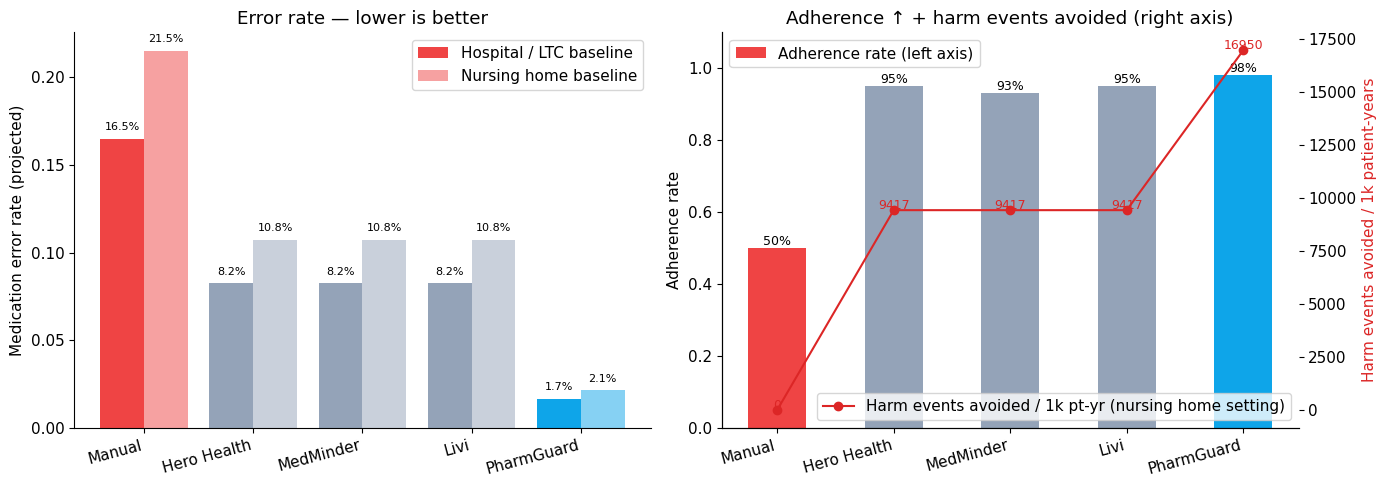

Sources (unique):
 - https://dosepacker.com/blog/medication-errors-statistics
 - https://www.rosewood-nursing.com/post/nursing-home-medication-error-statistics
 - https://formative.jmir.org/2022/5/e34906/
 - https://pmc.ncbi.nlm.nih.gov/articles/PMC7807760/


In [7]:
df_out = pd.read_csv(DATA / "outcomes.csv")

# Errors and harm events per 1k patient-years
df_out["errors_per_1k_py"] = df_out["events_per_day"] * 365 * 1000 * df_out["product_error_rate"]
df_out["harm_per_1k_py"]   = df_out["errors_per_1k_py"] * df_out["harm_fraction"]
manual_by_setting = df_out[df_out["product"] == "Manual"].set_index("baseline_setting")["errors_per_1k_py"]
df_out["avoided_harm_per_1k_py"] = df_out.apply(
    lambda r: (manual_by_setting[r["baseline_setting"]] - r["errors_per_1k_py"]) * r["harm_fraction"], axis=1
)

# Chart 1: error rate per product, both baseline settings
products = df_out["product"].unique().tolist()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(products))
hosp = [df_out[(df_out["product"] == p) & (df_out["baseline_setting"] == "hospital_ltc")]["product_error_rate"].iloc[0] for p in products]
nurs = [df_out[(df_out["product"] == p) & (df_out["baseline_setting"] == "nursing_home")]["product_error_rate"].iloc[0] for p in products]
colors = [colour_for(p) for p in products]
ax1.bar(x - 0.2, hosp, 0.4, color=colors, label="Hospital / LTC baseline")
ax1.bar(x + 0.2, nurs, 0.4, color=colors, alpha=0.5, label="Nursing home baseline")
for i, (h, n) in enumerate(zip(hosp, nurs)):
    ax1.text(i - 0.2, h + 0.005, f"{h*100:.1f}%", ha="center", fontsize=8)
    ax1.text(i + 0.2, n + 0.005, f"{n*100:.1f}%", ha="center", fontsize=8)
ax1.set_xticks(x); ax1.set_xticklabels(products, rotation=15, ha="right")
ax1.set_ylabel("Medication error rate (projected)")
ax1.set_title("Error rate — lower is better")
ax1.legend()

# Chart 2: adherence + avoided harm
adh = [df_out[(df_out["product"] == p) & (df_out["baseline_setting"] == "hospital_ltc")]["product_adherence"].iloc[0] for p in products]
avoided = [df_out[(df_out["product"] == p) & (df_out["baseline_setting"] == "nursing_home")]["avoided_harm_per_1k_py"].iloc[0] for p in products]

ax2.bar(x, adh, 0.5, color=colors, label="Adherence rate (left axis)")
for i, v in enumerate(adh):
    ax2.text(i, v + 0.01, f"{v*100:.0f}%", ha="center", fontsize=9)
ax2.set_ylim(0, 1.1)
ax2.set_ylabel("Adherence rate")
ax2.set_xticks(x); ax2.set_xticklabels(products, rotation=15, ha="right")
ax2.set_title("Adherence ↑ + harm events avoided (right axis)")

ax2b = ax2.twinx()
ax2b.spines["top"].set_visible(False)
ax2b.plot(x, avoided, "o-", color="#dc2626", label="Harm events avoided / 1k pt-yr (nursing home setting)")
for i, v in enumerate(avoided):
    ax2b.text(i, v + 50, f"{int(v)}", ha="center", color="#dc2626", fontsize=9)
ax2b.set_ylabel("Harm events avoided / 1k patient-years", color="#dc2626")
ax2.legend(loc="upper left"); ax2b.legend(loc="lower right")

plt.tight_layout(); plt.show()

print("Sources (unique):")
for url in df_out["source_url"].unique():
    print(" -", url)


## §6c  Hospital fleet scalability + workforce-shortage offset

How does PharmGuard scale to **every corner of a hospital**, and how does the *total fleet cost* compare with simply hiring enough nurses (and pharmacists) to perform the same med-admin work manually?

**Why this matters now.** WHO (May 2025) reports a global nursing deficit of ~5.8 M; ICN projects up to 13 M by 2030 if no action is taken. The US faces a ~5,000-pharmacist shortfall through 2036. Hospitals cannot simply hire their way out — automation that offloads repeatable med-admin work directly reduces the FTE gap.

Model assumptions (all editable in `data/fleet_scenario.csv` and `data/staffing_baseline.csv`):
- 1 PharmGuard dispenser per ~4 beds (mirrors the 1:4 RN day-shift ratio).
- 11 min/patient × 3 med events/day = **33 min/patient/day** of nurse med-admin time (PMC 12685314).
- Loaded RN cost = hourly wage × 1.4 burden multiplier.
- PharmGuard offloads 90 % of that time (intake confirmed by FSM, no nurse stand-over).
- Hardware ~$150/unit BOM, ~$5/mo subscription (BYO-hardware tier).

,hospital_size_label,total_dispensers,fleet_tco_3y,manual_med_admin_cost_3y,pg_total_3y,savings_3y,nurse_fte_for_med_admin,fte_offset,pharmacist_count,pharmacist_cost_3y
0,Small community (100 beds),25,8250,3989786.0,407229.0,3582557.0,10.0,9.0,2,907200
1,Standard community (250 beds),63,20790,9974464.0,1018236.0,8956228.0,24.0,22.0,4,1814400
2,Regional (500 beds),125,41250,19948929.0,2036143.0,17912786.0,48.0,43.0,8,3628800
3,Academic medical centre (1000 beds),250,82500,39897858.0,4072286.0,35825572.0,97.0,87.0,15,6804000


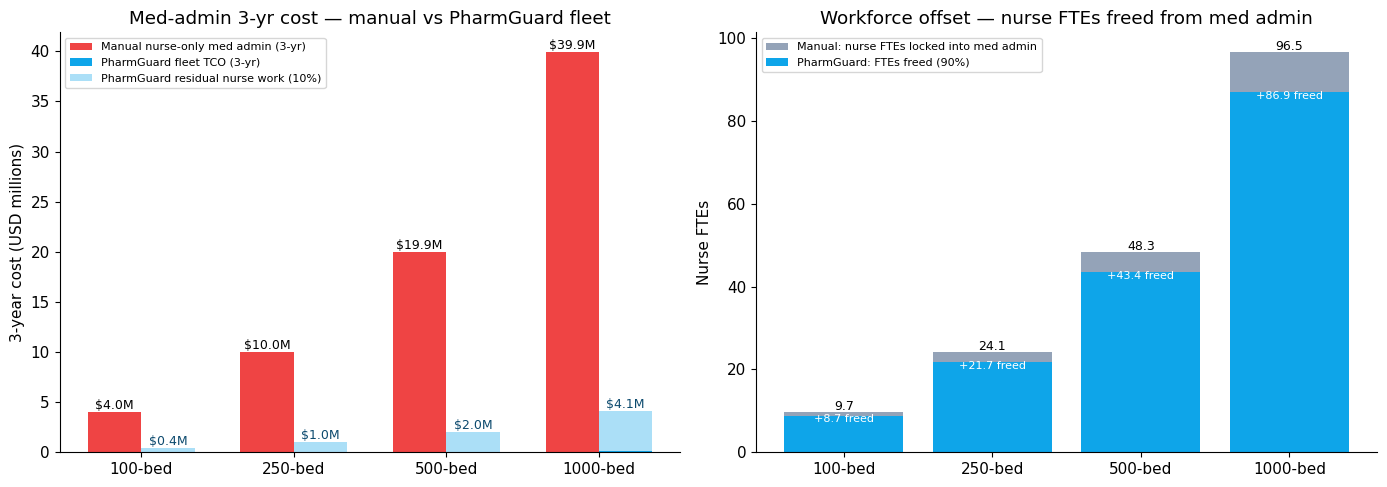


--- Workforce-shortage context ---
  Global   Nurse      baseline deficit:    5,800,000  |  2030 projection: 4,100,000
  Global   Nurse      baseline deficit:    5,800,000  |  2030 projection: 13,000,000
  USA      Pharmacist baseline deficit:          n/a  |  2036 projection: 5,000

Standard 250-bed community hospital, 3-year horizon:
  Manual nurse-only med admin cost   : $9.97 M
  PharmGuard fleet (63 units) + 10% residual: $1.02 M
  Net 3-yr savings                   : $8.96 M (90% lower)
  Nurse FTEs freed for non-med-admin clinical work: 21.7
  Fleet hardware payback vs manual cost: 0.0 months


In [8]:
df_fleet = pd.read_csv(DATA / "fleet_scenario.csv")
df_staff = pd.read_csv(DATA / "staffing_baseline.csv")
df_short = pd.read_csv(DATA / "shortage.csv")

df = df_fleet.merge(df_staff, on=["hospital_size_label", "total_beds"], how="left")

YEARS = 3
df["fleet_hardware_cost"]   = df["total_dispensers"] * df["hardware_unit_cost"]
df["fleet_subscription_3y"] = df["total_dispensers"] * df["subscription_monthly"] * 12 * YEARS
df["fleet_tco_3y"]          = df["fleet_hardware_cost"] + df["fleet_subscription_3y"]

# Manual nurse-only labour cost for med admin (3-yr)
df["med_admin_hours_per_year"] = df["total_beds"] * df["med_admin_minutes_per_patient_per_day"] * 365 / 60
df["loaded_nurse_hourly"]      = df["nurse_hourly_wage"] * df["nurse_burden_multiplier"]
df["nurse_fte_for_med_admin"]  = df["med_admin_hours_per_year"] / 2080  # 1 FTE = 2080 hr/yr
df["manual_med_admin_cost_3y"] = df["med_admin_hours_per_year"] * df["loaded_nurse_hourly"] * YEARS

# PharmGuard residual nurse cost (10% of manual)
df["pg_residual_nurse_cost_3y"] = df["manual_med_admin_cost_3y"] * 0.10
df["pg_total_3y"]               = df["fleet_tco_3y"] + df["pg_residual_nurse_cost_3y"]
df["savings_3y"]                = df["manual_med_admin_cost_3y"] - df["pg_total_3y"]
df["fte_offset"]                = df["nurse_fte_for_med_admin"] * 0.90

# Pharmacist cost context (full salary, not med-admin specific — they handle order verification, IV admixture, etc.)
df["pharmacist_count"]          = (df["total_beds"] / 100 * df["pharmacists_per_100_beds"]).round().astype(int)
df["pharmacist_cost_3y"]        = df["pharmacist_count"] * df["hospital_pharmacist_annual_salary"] * YEARS

summary_cols = ["hospital_size_label", "total_dispensers", "fleet_tco_3y",
                "manual_med_admin_cost_3y", "pg_total_3y", "savings_3y",
                "nurse_fte_for_med_admin", "fte_offset",
                "pharmacist_count", "pharmacist_cost_3y"]
display(df[summary_cols].round(0))

# Chart 1: 3-yr cost stacks per hospital size — manual nurse vs PharmGuard fleet
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(df))
w = 0.35
ax1.bar(x - w/2, df["manual_med_admin_cost_3y"] / 1e6, w,
        color="#ef4444", label="Manual nurse-only med admin (3-yr)")
ax1.bar(x + w/2, df["fleet_tco_3y"] / 1e6, w,
        color="#0ea5e9", label="PharmGuard fleet TCO (3-yr)")
ax1.bar(x + w/2, df["pg_residual_nurse_cost_3y"] / 1e6, w,
        bottom=df["fleet_tco_3y"] / 1e6, color="#0ea5e9", alpha=0.35,
        label="PharmGuard residual nurse work (10%)")
for i, (m, p) in enumerate(zip(df["manual_med_admin_cost_3y"]/1e6, df["pg_total_3y"]/1e6)):
    ax1.text(i - w/2, m + 0.3, f"${m:.1f}M", ha="center", fontsize=9)
    ax1.text(i + w/2, p + 0.3, f"${p:.1f}M", ha="center", fontsize=9, color="#0c4a6e")
ax1.set_xticks(x); ax1.set_xticklabels(df["total_beds"].astype(str) + "-bed", rotation=0)
ax1.set_ylabel("3-year cost (USD millions)")
ax1.set_title("Med-admin 3-yr cost — manual vs PharmGuard fleet")
ax1.legend(fontsize=8)

# Chart 2: FTE offset — nurses freed from med-admin per hospital scale
colors2 = ["#94a3b8"] * len(df)
ax2.bar(x, df["nurse_fte_for_med_admin"], color=colors2,
        label="Manual: nurse FTEs locked into med admin")
ax2.bar(x, df["fte_offset"], color="#0ea5e9",
        label="PharmGuard: FTEs freed (90%)")
for i, (m, o) in enumerate(zip(df["nurse_fte_for_med_admin"], df["fte_offset"])):
    ax2.text(i, m + 0.5, f"{m:.1f}", ha="center", fontsize=9)
    ax2.text(i, o - 1.5, f"+{o:.1f} freed", ha="center", fontsize=8, color="white")
ax2.set_xticks(x); ax2.set_xticklabels(df["total_beds"].astype(str) + "-bed", rotation=0)
ax2.set_ylabel("Nurse FTEs")
ax2.set_title("Workforce offset — nurse FTEs freed from med admin")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Shortage context callout
print("\n--- Workforce-shortage context ---")
for _, r in df_short.iterrows():
    base = f"{int(r['baseline_deficit']):,}" if pd.notna(r['baseline_deficit']) else "n/a"
    proj = f"{int(r['projected_deficit']):,}" if pd.notna(r['projected_deficit']) else "n/a"
    print(f"  {r['region']:8s} {r['role']:10s} baseline deficit: {base:>12s}  |  {r['projection_year']} projection: {proj}")

# Headline result
std = df[df["total_beds"] == 250].iloc[0]
print(f"\nStandard 250-bed community hospital, 3-year horizon:")
print(f"  Manual nurse-only med admin cost   : ${std['manual_med_admin_cost_3y']/1e6:,.2f} M")
print(f"  PharmGuard fleet ({int(std['total_dispensers'])} units) + 10% residual: ${std['pg_total_3y']/1e6:,.2f} M")
print(f"  Net 3-yr savings                   : ${std['savings_3y']/1e6:,.2f} M ({std['savings_3y']/std['manual_med_admin_cost_3y']*100:.0f}% lower)")
print(f"  Nurse FTEs freed for non-med-admin clinical work: {std['fte_offset']:.1f}")
print(f"  Fleet hardware payback vs manual cost: {std['fleet_hardware_cost']/(std['manual_med_admin_cost_3y']/36):.1f} months")


## §7  Standards conformance heatmap

`designed-toward=2`, `partial=1`, `out-of-scope=0`, `unknown=grey (NaN)`.

/var/folders/jf/68kxw3qn4rx5ggbh2jqt57mw0000gn/T/ipykernel_86043/1002194440.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Blues", 3).copy()


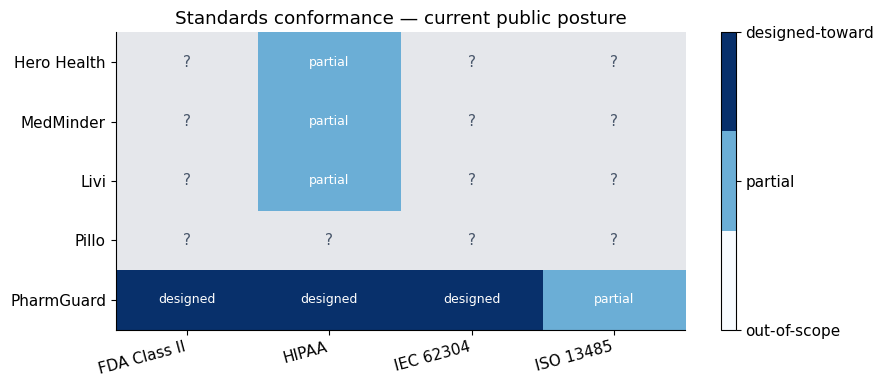

In [9]:
df_std = pd.read_csv(DATA / "standards.csv")
status_map = {"designed-toward": 2, "partial": 1, "out-of-scope": 0, "unknown": np.nan}
df_std["score"] = df_std["status"].map(status_map)

pivot = df_std.pivot(index="product", columns="standard", values="score")
# Order rows so PharmGuard last
order = [p for p in ["Hero Health","MedMinder","Livi","Pillo","PharmGuard"] if p in pivot.index]
pivot = pivot.reindex(order)

fig, ax = plt.subplots(figsize=(9, 4))
cmap = plt.cm.get_cmap("Blues", 3).copy()
cmap.set_bad("#e5e7eb")
im = ax.imshow(pivot.values, cmap=cmap, vmin=0, vmax=2, aspect="auto")
ax.set_xticks(np.arange(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=15, ha="right")
ax.set_yticks(np.arange(len(pivot.index))); ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if np.isnan(v):
            ax.text(j, i, "?", ha="center", va="center", color="#475569")
        else:
            label = {0:"out", 1:"partial", 2:"designed"}[int(v)]
            ax.text(j, i, label, ha="center", va="center", color="white" if v >= 1 else "#1e293b", fontsize=9)
ax.set_title("Standards conformance — current public posture")
cbar = plt.colorbar(im, ax=ax, ticks=[0,1,2])
cbar.ax.set_yticklabels(["out-of-scope","partial","designed-toward"])
plt.tight_layout(); plt.show()


## §8  Weighted scorecard + sensitivity

Seeded weights match the project rubric: Innovation 0.30, Industry-fit 0.20, Benchmarking 0.30, Commercialization 0.20. Equal-weight sensitivity also printed.

Seeded weights ranking:
  1. PharmGuard: 8.60
  2. Hero Health: 6.50
  3. Livi: 5.60
  4. MedMinder: 5.30
  5. Pillo: 4.90

Equal weights ranking:
  1. PharmGuard: 8.50
  2. Hero Health: 6.75
  3. Livi: 5.75
  4. MedMinder: 5.50
  5. Pillo: 4.75

Rank stable: PharmGuard is #1 under both weight schemes.


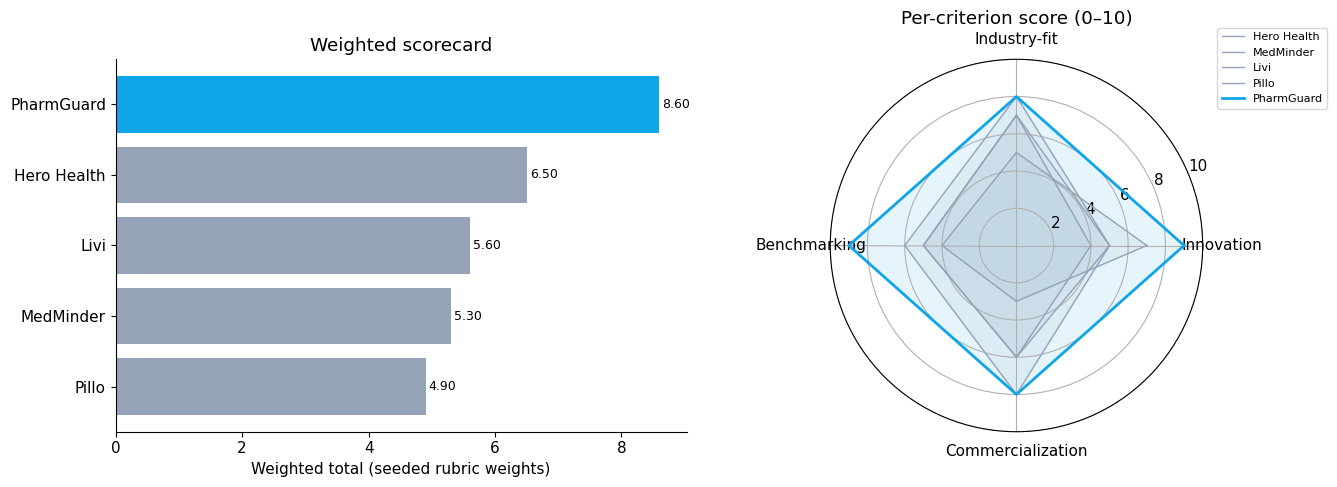

In [10]:
df_sc = pd.read_csv(DATA / "scorecard_weights.csv")
products_sc = [c for c in df_sc.columns if c not in ("criterion","weight","source_url")]

def rank(weights):
    totals = {}
    for p in products_sc:
        totals[p] = float((df_sc[p] * weights).sum())
    return sorted(totals.items(), key=lambda kv: -kv[1])

seeded = rank(df_sc["weight"].values)
equal  = rank(np.full(len(df_sc), 1/len(df_sc)))

print("Seeded weights ranking:")
for i, (p, s) in enumerate(seeded, 1): print(f"  {i}. {p}: {s:.2f}")
print("\nEqual weights ranking:")
for i, (p, s) in enumerate(equal, 1): print(f"  {i}. {p}: {s:.2f}")

top_seeded = seeded[0][0]; top_equal = equal[0][0]
if top_seeded != top_equal:
    print(f"\n  WARNING: rank flips between weight schemes. Seeded #1 = {top_seeded}, equal #1 = {top_equal}.")
else:
    print(f"\nRank stable: {top_seeded} is #1 under both weight schemes.")

# Two-panel: bar + radar
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(1, 2, 1)
names = [p for p, _ in seeded]
scores = [s for _, s in seeded]
colors = [colour_for(p) for p in names]
ax1.barh(names, scores, color=colors)
for i, v in enumerate(scores): ax1.text(v + 0.05, i, f"{v:.2f}", va="center", fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel("Weighted total (seeded rubric weights)")
ax1.set_title("Weighted scorecard")

ax2 = fig.add_subplot(1, 2, 2, projection="polar")
angles = np.linspace(0, 2*np.pi, len(df_sc), endpoint=False).tolist()
angles += angles[:1]
for p in products_sc:
    vals = df_sc[p].tolist() + [df_sc[p].iloc[0]]
    ax2.plot(angles, vals, color=colour_for(p), linewidth=2 if p == "PharmGuard" else 1, label=p)
    ax2.fill(angles, vals, color=colour_for(p), alpha=0.1)
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(df_sc["criterion"])
ax2.set_yticks([2,4,6,8,10])
ax2.set_title("Per-criterion score (0–10)")
ax2.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8)

plt.tight_layout(); plt.show()


---
*End of benchmark notebook. Update CSVs in `./data/` and re-run to refresh.*